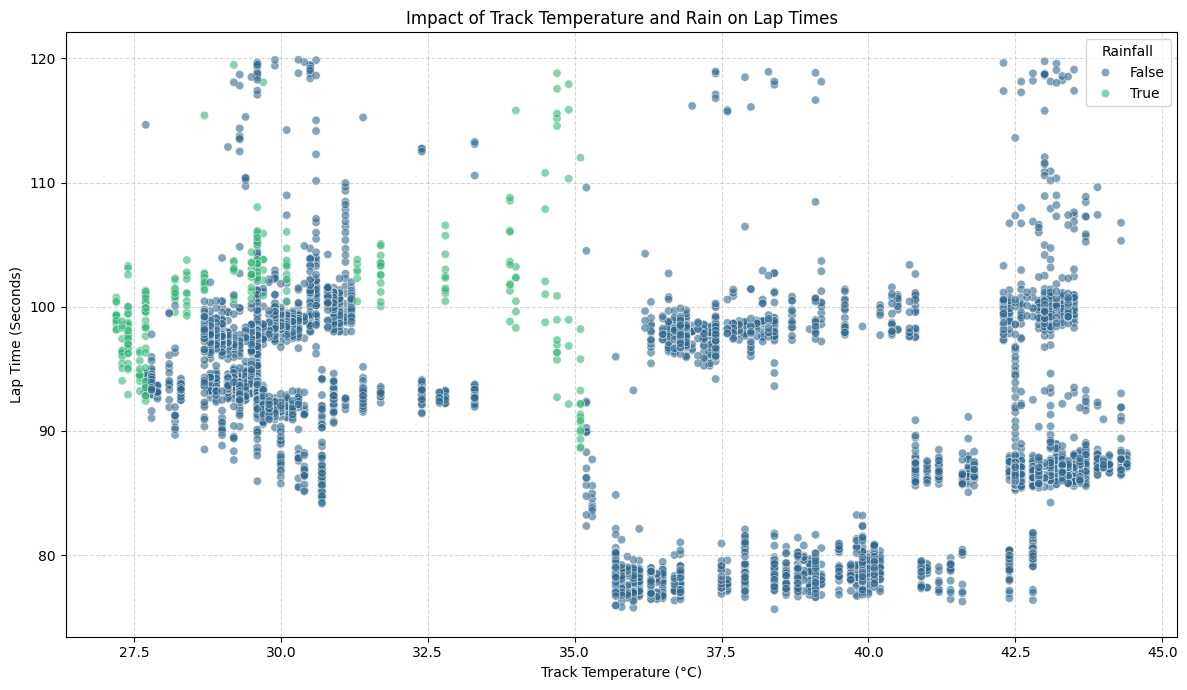

In [ ]:
# Cell 1: Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load processed data
laps_df = pd.read_csv('../data/processed/cleaned_laps.csv')
weather_df = pd.read_csv('../data/processed/weather_data.csv')

# Cell 2: Timestamp Conversion and Merging
# Convert timedelta strings to minutes for a rolling merge
laps_df['Time_m'] = pd.to_timedelta(laps_df['Time']).dt.total_seconds() // 60
weather_df['Time_m'] = pd.to_timedelta(weather_df['Time']).dt.total_seconds() // 60

# Merge closest weather data point to each lap
merged_data = pd.merge_asof(
    laps_df.sort_values('Time_m'),
    weather_df.sort_values('Time_m'),
    on='Time_m',
    by='Race',
    direction='nearest'
)

# Cell 3: Track Temperature and Rain Visualization
os.makedirs('../reports/figures', exist_ok=True)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=merged_data[merged_data['LapTime_s'] < 120], # Filter massive outliers/pit stops
    x='TrackTemp', 
    y='LapTime_s', 
    hue='Rainfall', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Impact of Track Temperature and Rain on Lap Times')
plt.xlabel('Track Temperature (°C)')
plt.ylabel('Lap Time (Seconds)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save high-res image for Member 3's Markdown documentation
plt.savefig('../reports/figures/weather_impact.png', dpi=300)
plt.show()